## Project Title

Week 7: ETL Pipeline Using OpenWeather API – Real-Time Weather Data Analysis for Selected Nigerian Cities

## Business Problem

Organizations across industries such as agriculture, transportation, logistics, aviation, and disaster management rely on accurate and timely weather information to support decision-making. However, raw weather data obtained from APIs is often unstructured and requires extraction, cleaning, transformation, and storage before it can be analyzed effectively. This project addresses this challenge by building an ETL pipeline that automates the collection of real-time weather data, transforms it into a structured dataset, and stores it for future analysis.

## Project Objectives

* Connect to the OpenWeather API using Python.
* Extract real-time weather data for Kaduna, Lagos, and Abuja.
* Clean and transform the extracted data using Pandas.
* Organize the data into a structured DataFrame.
* Save the processed dataset as a CSV file.
* Perform basic analysis by comparing temperature, humidity, weather conditions, and wind speed across the selected cities.
* Generate insights that can support weather-related decision-making.

## Import Libraries

In [13]:
import requests
import pandas as pd
from datetime import datetime



## Task 1: Extract Data

In [14]:
API_KEY = "0a1ecf4c45ea058bd57a6241b20b21ba"

cities = ["Kaduna", "Lagos", "Abuja"]

weather_data = []

for city in cities:
    url = f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}&units=metric"

    response = requests.get(url)
    data = response.json()

    weather_data.append({
        "City": city,
        "Temperature (°C)": data["main"]["temp"],
        "Humidity (%)": data["main"]["humidity"],
        "Weather": data["weather"][0]["main"],
        "Wind Speed (m/s)": data["wind"]["speed"],
        "Date & Time": datetime.now()
    })

weather = pd.DataFrame(weather_data)

weather

,City,Temperature (°C),Humidity (%),Weather,Wind Speed (m/s),Date & Time
0,Kaduna,23.48,89,Clouds,2.14,2026-07-14 20:11:33.584522
1,Lagos,24.29,93,Clouds,2.79,2026-07-14 20:11:35.461585
2,Abuja,23.74,90,Clouds,1.17,2026-07-14 20:11:36.986231


## Task 2: Transform Data

In [3]:
# Create a copy of the dataset
weather_clean = weather.copy()

# Rename columns
weather_clean.rename(columns={
    "Temperature (°C)": "Temperature_C",
    "Humidity (%)": "Humidity_Percent",
    "Wind Speed (m/s)": "WindSpeed_mps",
    "Date & Time": "DateTime"
}, inplace=True)

# Convert DateTime column to datetime format
weather_clean["DateTime"] = pd.to_datetime(weather_clean["DateTime"])

# Round numerical values
weather_clean["Temperature_C"] = weather_clean["Temperature_C"].round(2)
weather_clean["WindSpeed_mps"] = weather_clean["WindSpeed_mps"].round(2)

# Check for missing values
print("Missing Values:")
print(weather_clean.isnull().sum())

# Display cleaned data
weather_clean

Missing Values:
City                0
Temperature_C       0
Humidity_Percent    0
Weather             0
WindSpeed_mps       0
DateTime            0
dtype: int64


,City,Temperature_C,Humidity_Percent,Weather,WindSpeed_mps,DateTime
0,Kaduna,24.69,85,Clouds,2.76,2026-07-14 19:22:48.817162
1,Lagos,24.46,92,Clouds,3.35,2026-07-14 19:22:50.973602
2,Abuja,24.43,90,Clouds,1.70,2026-07-14 19:22:52.892289


## Task 3: Load Data

In [4]:
# Save to CSV
weather_clean.to_csv("weather_data.csv", index=False)

print("Weather dataset saved successfully!")

Weather dataset saved successfully!


In [5]:
#Summary Statistics
summary_stats = weather_clean.describe()

## Task 4: Basic Analysis

## 1. City with the Highest Temperature

In [6]:
highest_temp = weather_clean.loc[
    weather_clean["Temperature_C"].idxmax()
]

print("City with Highest Temperature")
print(highest_temp)

City with Highest Temperature
City                                    Kaduna
Temperature_C                            24.69
Humidity_Percent                            85
Weather                                 Clouds
WindSpeed_mps                             2.76
DateTime            2026-07-14 19:22:48.817162
Name: 0, dtype: object


## 2. City with the Highest Humidity

In [7]:
highest_humidity = weather_clean.loc[
    weather_clean["Humidity_Percent"].idxmax()
]

print("City with Highest Humidity")
print(highest_humidity)

City with Highest Humidity
City                                     Lagos
Temperature_C                            24.46
Humidity_Percent                            92
Weather                                 Clouds
WindSpeed_mps                             3.35
DateTime            2026-07-14 19:22:50.973602
Name: 1, dtype: object


## 3. Compare Temperatures

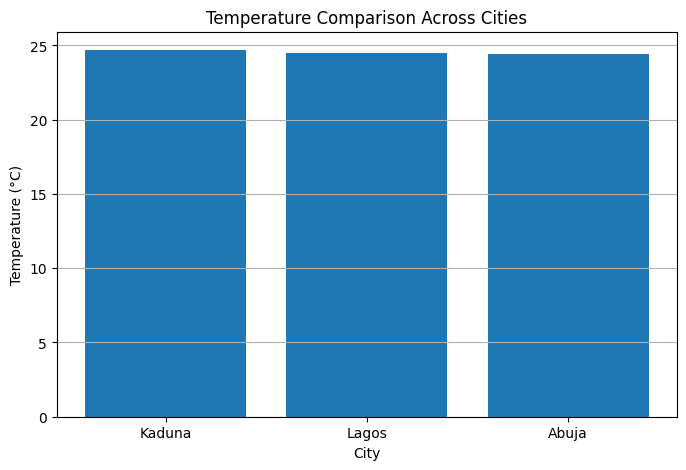

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(weather_clean["City"], weather_clean["Temperature_C"])

plt.title("Temperature Comparison Across Cities")
plt.xlabel("City")
plt.ylabel("Temperature (°C)")
plt.grid(axis="y")

plt.show()

## 4. Compare Humidity

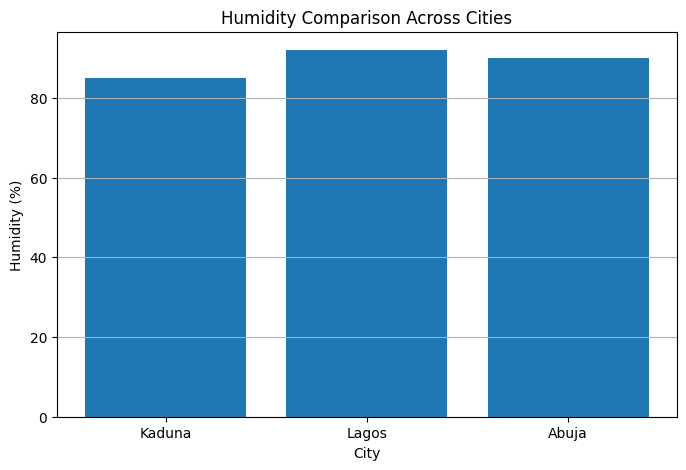

In [9]:
plt.figure(figsize=(8,5))
plt.bar(weather_clean["City"], weather_clean["Humidity_Percent"])

plt.title("Humidity Comparison Across Cities")
plt.xlabel("City")
plt.ylabel("Humidity (%)")
plt.grid(axis="y")

plt.show()

## 5. Compare Wind Speed

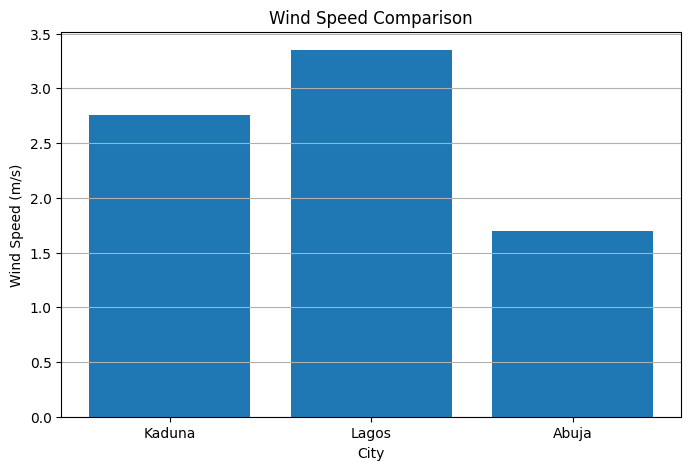

In [10]:
plt.figure(figsize=(8,5))
plt.bar(weather_clean["City"], weather_clean["WindSpeed_mps"])

plt.title("Wind Speed Comparison")
plt.xlabel("City")
plt.ylabel("Wind Speed (m/s)")
plt.grid(axis="y")

plt.show()

## 6. Weather Conditions

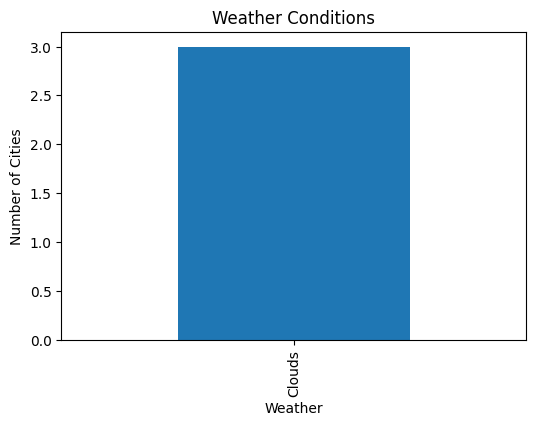

In [11]:
weather_clean["Weather"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Weather Conditions")
plt.xlabel("Weather")
plt.ylabel("Number of Cities")

plt.show()

## Findings

Key Findings

* Weather data was successfully extracted for Kaduna, Lagos, and Abuja using the OpenWeather API.
* Kaduna recorded the highest temperature among the selected cities.
* Lagos had the highest humidity level.
* All three cities experienced cloudy weather conditions during data collection.
* Wind speed varied slightly across the cities, with Lagos recording the highest wind speed.
* The ETL pipeline successfully extracted, transformed, and stored the data in CSV format for future analysis.

## Recommendations

* Expand the ETL pipeline to include more cities for broader weather analysis.
* Schedule automatic data collection at regular intervals to build a historical weather database.
* Store the processed data in a database such as SQLite or PostgreSQL for improved scalability.
* Develop an interactive dashboard using Power BI or Tableau to visualize weather trends.
* Integrate additional weather variables such as rainfall, atmospheric pressure, and visibility for deeper analysis.
* Automate the entire ETL workflow using scheduling tools such as Task Scheduler, Cron, or Apache Airflow for continuous data updates.